<a href="https://colab.research.google.com/github/ummasalmaj2004-netizen/camera/blob/main/Superstore_Market_Basket_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Market Basket Analysis

Market Basket Analysis (MBA) is a data mining technique used to discover relationships and purchasing patterns among items that are frequently purchased together. It helps businesses understand which products tend to occur in the same transaction and can be used to support decisions such as product recommendations, promotions, cross-selling, and product placement.

In this project, Market Basket Analysis will be applied to the Superstore dataset to identify products that are commonly purchased together. The analysis will use transaction-level information, where products belonging to the same order are treated as items in one transaction.

The analysis will generate frequent itemsets and association rules. The rules will then be evaluated using measures such as **support, confidence, and lift** to identify meaningful relationships between products.

### Steps for Market Basket Analysis

1. **Import the required libraries**

2. **Load the Superstore dataset**

3. **Explore the dataset**

4. **Select relevant attributes**

5. **Clean and prepare the data**

6. **Create transaction baskets**

7. **Encode the transactions**

8. **Generate frequent itemsets**

9. **Generate association rules**

10. **Evaluate the association rules**

11. **Experiment with different thresholds**

12. **Analyse and visualise the results**

13. **Interpret the findings**

14. **Develop practical recommendations**
   
15. **Connect the findings with the other project components**

    

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules

In [ ]:
# 2 Load the Superstore dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

# Display the first five records
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# 3 Exploring Dataset

print("Dataset shape:", df.shape)

print("Columns in the dataset:")
print(df.columns.tolist())

df.info()

df.describe(include="all").T

missing_values = df.isnull().sum()

print("Missing values by column:")
print(missing_values)

Dataset shape: (9994, 21)
Columns in the dataset:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal

In [ ]:
# 4 Selecting The Attribute

mba_df = df[
    [
        "Order ID",
        "Product ID",
        "Product Name",
        "Category",
        "Sub-Category",
        "Quantity",
        "Sales",
        "Profit"
    ]
].copy()

mba_df.head()

,Order ID,Product ID,Product Name,Category,Sub-Category,Quantity,Sales,Profit
0,CA-2016-152156,FUR-BO-10001798,Bush Somerset Collection Bookcase,Furniture,Bookcases,2,261.9600,41.9136
1,CA-2016-152156,FUR-CH-10000454,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Furniture,Chairs,3,731.9400,219.5820
2,CA-2016-138688,OFF-LA-10000240,Self-Adhesive Address Labels for Typewriters b...,Office Supplies,Labels,2,14.6200,6.8714
3,US-2015-108966,FUR-TA-10000577,Bretford CR4500 Series Slim Rectangular Table,Furniture,Tables,5,957.5775,-383.0310
4,US-2015-108966,OFF-ST-10000760,Eldon Fold 'N Roll Cart System,Office Supplies,Storage,2,22.3680,2.5164


Due to the high number of individual products and the sparsity of product-level transactions, Sub-Category was used as the item level for association analysis to obtain computationally manageable and meaningful purchasing relationships.

In [ ]:
 # 5 Cleaning and Preparing The Data

 # Check missing values
mba_df[["Order ID", "Product Name"]].isnull().sum()

# Remove missing transaction/product values
mba_df = mba_df.dropna(
    subset=["Order ID", "Product Name"]
)

# Clean product names
mba_df["Product Name"] = mba_df["Product Name"].str.strip()

# Remove duplicate order-product combinations
mba_df = mba_df.drop_duplicates(
    subset=["Order ID", "Product Name"]
)

# Check the cleaned dataset
print("Shape after cleaning:", mba_df.shape)



Shape after cleaning: (9986, 8)


In [ ]:
# 6. Create transaction baskets

basket = (
    mba_df.groupby(
        ["Order ID", "Sub-Category"]
    )["Sub-Category"]
    .count()
    .unstack()
    .fillna(0)
)

print("Basket shape:", basket.shape)
basket.head()

Basket shape: (5009, 17)


Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Order ID,,,,,,,,,,,,,,,,,
CA-2014-100006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
CA-2014-100090,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
CA-2014-100293,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
CA-2014-100328,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA-2014-100363,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [ ]:
# 7. Encode the transactions

basket_encoded = (basket > 0).astype("int8")

print("Encoded basket shape:", basket_encoded.shape)
print("Unique values:", np.unique(basket_encoded.values))

Encoded basket shape: (5009, 17)
Unique values: [0 1]


In [ ]:
# 8. Generate frequent itemsets

min_support = 0.01

frequent_itemsets = apriori(
    basket_encoded,
    min_support=min_support,
    use_colnames=True,
    max_len=2
)

frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

print("Number of frequent itemsets:", len(frequent_itemsets))

frequent_itemsets.head(20)

Number of frequent itemsets: 65


,support,itemsets
3,0.262727,(Binders)
12,0.237772,(Paper)
9,0.175085,(Furnishings)
13,0.162507,(Phones)
14,0.155121,(Storage)
2,0.145937,(Art)
0,0.143342,(Accessories)
5,0.114993,(Chairs)
1,0.090038,(Appliances)
10,0.069076,(Labels)


In [ ]:
# 9. Generate association rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.20
)

rules = rules.sort_values(
    by="lift",
    ascending=False
)

print("Number of association rules:", len(rules))

rules.head(20)

Number of association rules: 24


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
20,(Fasteners),(Paper),0.042923,0.237772,0.011779,0.274419,1.154125,1.0,0.001573,1.050507,0.139532,0.043801,0.048078,0.161978
19,(Fasteners),(Binders),0.042923,0.262727,0.012378,0.288372,1.097611,1.0,0.001101,1.036037,0.092919,0.042206,0.034784,0.167742
13,(Appliances),(Binders),0.090038,0.262727,0.025953,0.288248,1.097140,1.0,0.002298,1.035857,0.097300,0.079414,0.034616,0.193516
15,(Appliances),(Paper),0.090038,0.237772,0.021761,0.241685,1.016458,1.0,0.000352,1.005160,0.017793,0.071102,0.005134,0.166602
3,(Storage),(Binders),0.155121,0.262727,0.039728,0.256113,0.974826,1.0,-0.001026,0.991109,-0.029659,0.105069,-0.008971,0.203665
17,(Labels),(Paper),0.069076,0.237772,0.015971,0.231214,0.972418,1.0,-0.000453,0.991469,-0.029568,0.054907,-0.008604,0.149192
12,(Chairs),(Paper),0.114993,0.237772,0.026552,0.230903,0.971110,1.0,-0.000790,0.991068,-0.032522,0.081395,-0.009012,0.171287
5,(Storage),(Paper),0.155121,0.237772,0.035536,0.229086,0.963470,1.0,-0.001347,0.988733,-0.042949,0.099441,-0.011395,0.189270
21,(Envelopes),(Paper),0.049711,0.237772,0.011380,0.228916,0.962753,1.0,-0.000440,0.988514,-0.039119,0.041215,-0.011619,0.138387
22,(Bookcases),(Binders),0.044720,0.262727,0.011180,0.250000,0.951558,1.0,-0.000569,0.983031,-0.050595,0.037736,-0.017262,0.146277


In [ ]:
# 10. Evaluate the association rules

rules_evaluation = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].copy()

# Convert frozensets into readable text
rules_evaluation["antecedents"] = rules_evaluation[
    "antecedents"
].apply(lambda x: ", ".join(x))

rules_evaluation["consequents"] = rules_evaluation[
    "consequents"
].apply(lambda x: ", ".join(x))

# Sort by lift
rules_evaluation = rules_evaluation.sort_values(
    by="lift",
    ascending=False
)

rules_evaluation.head(20)

,antecedents,consequents,support,confidence,lift
20,Fasteners,Paper,0.011779,0.274419,1.154125
19,Fasteners,Binders,0.012378,0.288372,1.097611
13,Appliances,Binders,0.025953,0.288248,1.097140
15,Appliances,Paper,0.021761,0.241685,1.016458
3,Storage,Binders,0.039728,0.256113,0.974826
17,Labels,Paper,0.015971,0.231214,0.972418
12,Chairs,Paper,0.026552,0.230903,0.971110
5,Storage,Paper,0.035536,0.229086,0.963470
21,Envelopes,Paper,0.011380,0.228916,0.962753
22,Bookcases,Binders,0.011180,0.250000,0.951558


In [ ]:
# Top 10 strongest rules

strong_rules = rules_evaluation.head(10)

strong_rules

,antecedents,consequents,support,confidence,lift
20,Fasteners,Paper,0.011779,0.274419,1.154125
19,Fasteners,Binders,0.012378,0.288372,1.097611
13,Appliances,Binders,0.025953,0.288248,1.097140
15,Appliances,Paper,0.021761,0.241685,1.016458
3,Storage,Binders,0.039728,0.256113,0.974826
17,Labels,Paper,0.015971,0.231214,0.972418
12,Chairs,Paper,0.026552,0.230903,0.971110
5,Storage,Paper,0.035536,0.229086,0.963470
21,Envelopes,Paper,0.011380,0.228916,0.962753
22,Bookcases,Binders,0.011180,0.250000,0.951558


In [ ]:
# 11. Experiment with different minimum support values

support_values = [0.01, 0.02, 0.03, 0.05]

support_results = []

for support in support_values:

    itemsets = apriori(
        basket_encoded,
        min_support=support,
        use_colnames=True,
        max_len=2
    )

    multi_itemsets = itemsets[
        itemsets["itemsets"].apply(len) >= 2
    ]

    support_results.append({
        "Minimum Support": support,
        "Total Frequent Itemsets": len(itemsets),
        "Multi-Item Itemsets": len(multi_itemsets)
    })

support_results_df = pd.DataFrame(support_results)

support_results_df

,Minimum Support,Total Frequent Itemsets,Multi-Item Itemsets
0,0.01,65,48
1,0.02,38,22
2,0.03,24,9
3,0.05,12,1


In [ ]:
# Experiment with different confidence values

confidence_values = [0.10, 0.20, 0.30, 0.40, 0.50]

confidence_results = []

for confidence in confidence_values:

    test_rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=confidence
    )

    confidence_results.append({
        "Minimum Confidence": confidence,
        "Number of Rules": len(test_rules)
    })

confidence_results_df = pd.DataFrame(
    confidence_results
)

confidence_results_df

,Minimum Confidence,Number of Rules
0,0.1,74
1,0.2,24
2,0.3,0
3,0.4,0
4,0.5,0


In [ ]:
# 12. Analyse the strongest association rules

top_rules = rules_evaluation.head(10)

top_rules

,antecedents,consequents,support,confidence,lift
20,Fasteners,Paper,0.011779,0.274419,1.154125
19,Fasteners,Binders,0.012378,0.288372,1.097611
13,Appliances,Binders,0.025953,0.288248,1.097140
15,Appliances,Paper,0.021761,0.241685,1.016458
3,Storage,Binders,0.039728,0.256113,0.974826
17,Labels,Paper,0.015971,0.231214,0.972418
12,Chairs,Paper,0.026552,0.230903,0.971110
5,Storage,Paper,0.035536,0.229086,0.963470
21,Envelopes,Paper,0.011380,0.228916,0.962753
22,Bookcases,Binders,0.011180,0.250000,0.951558


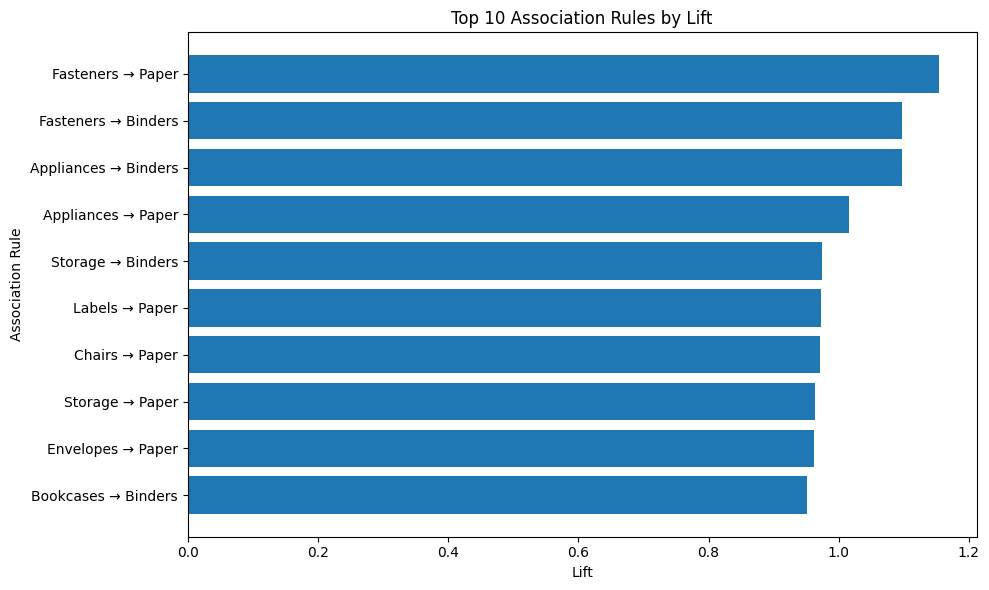

In [ ]:
# Visualisation 1 — Lift
plt.figure(figsize=(10, 6))

plot_data = rules.sort_values(
    by="lift",
    ascending=False
).head(10)

labels = [
    f"{', '.join(a)} → {', '.join(c)}"
    for a, c in zip(
        plot_data["antecedents"],
        plot_data["consequents"]
    )
]

plt.barh(
    labels,
    plot_data["lift"]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 10 Association Rules by Lift")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

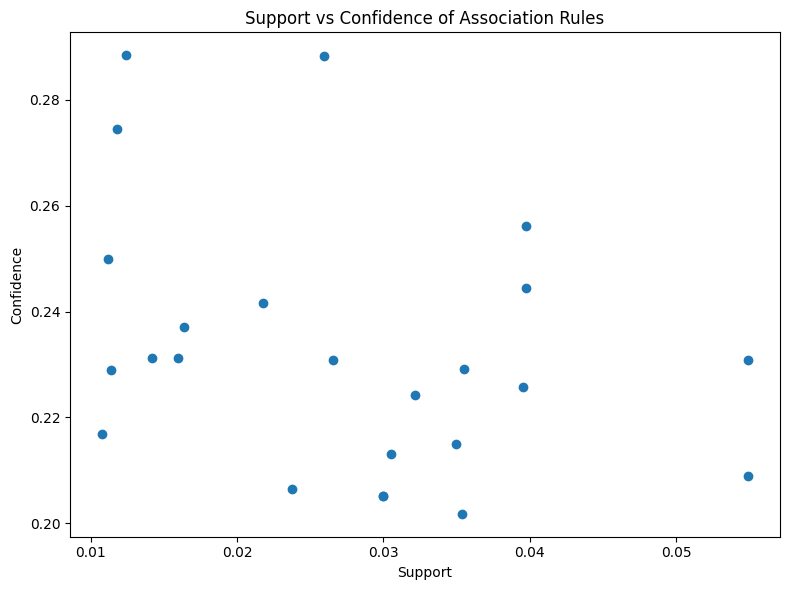

In [ ]:
# Visualisation 2 — Support vs Confidence

plt.figure(figsize=(8, 6))

plt.scatter(
    rules["support"],
    rules["confidence"]
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence of Association Rules")

plt.tight_layout()
plt.show()

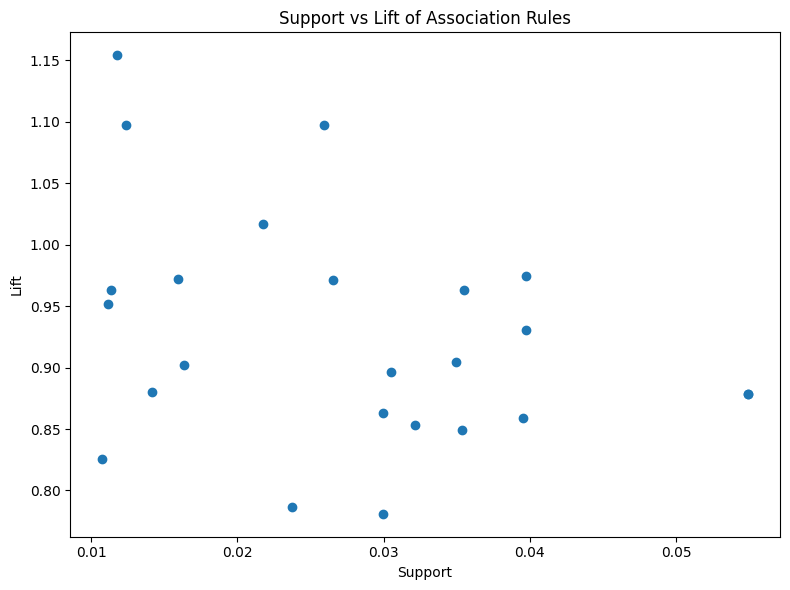

In [ ]:
# Support vs Lift
plt.figure(figsize=(8, 6))

plt.scatter(
    rules["support"],
    rules["lift"]
)

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Support vs Lift of Association Rules")

plt.tight_layout()
plt.show()

## 13. Interpret the Findings

The Market Basket Analysis identified relationships between items that were purchased within the same orders. The discovered association rules were evaluated using support, confidence, and lift.

Support indicates how frequently an item combination occurs across all transactions. Confidence indicates the likelihood that the consequent item is purchased when the antecedent item is purchased. Lift measures the strength of the relationship between the items compared with their expected occurrence if they were independent.

Rules with a lift greater than 1 indicate a positive association between the items. Therefore, the strongest rules can provide useful insights into customer purchasing behaviour and can support cross-selling, product recommendations, promotions, and product placement decisions.

In [ ]:
# Display the strongest rule

top_rule = rules.sort_values(
    by="lift",
    ascending=False
).iloc[0]

print("Strongest Association Rule")
print("--------------------------")
print("Antecedent:", list(top_rule["antecedents"]))
print("Consequent:", list(top_rule["consequents"]))
print("Support:", round(top_rule["support"], 4))
print("Confidence:", round(top_rule["confidence"], 4))
print("Lift:", round(top_rule["lift"], 4))

Strongest Association Rule
--------------------------
Antecedent: ['Fasteners']
Consequent: ['Paper']
Support: 0.0118
Confidence: 0.2744
Lift: 1.1541


## 14. Develop Practical Recommendations

Based on the Market Basket Analysis results, several practical business strategies can be recommended.

1. **Cross-selling:** Frequently associated items can be recommended to customers when they purchase a related item.

2. **Product bundling:** Items with strong associations can be combined into promotional bundles to encourage customers to purchase them together.

3. **Product recommendations:** Association rules can be incorporated into a recommendation system to suggest related items to customers.

4. **Promotional strategies:** Products with strong relationships can be included in joint promotions or special offers.

5. **Product placement:** Frequently associated items can be positioned near each other to make related products easier for customers to discover.

These strategies can help the business improve cross-selling opportunities, customer experience, and sales performance.

## 15. Connect the Findings with the Other Project Components

The Market Basket Analysis provides additional insight into customer purchasing behaviour by identifying items that frequently occur together in the same transaction.

These findings can be combined with the other analytical components of the project to provide a more complete understanding of the Superstore dataset.

For example, sales and profit analysis can identify products or categories that contribute strongly to business performance, while Market Basket Analysis identifies purchasing relationships between items.

Combining these findings can help the business make better decisions about product recommendations, cross-selling, product bundling, promotions, and product placement.

The Market Basket Analysis therefore complements the other project components by focusing specifically on relationships between items purchased within the same order.